# Extracting Dataset using kaggle API

In [2]:
# installing the kaggle library
!pip install kaggle

In [47]:
# configuring the path of Kaggle.json file
import os
import shutil
home = os.path.expanduser("~")
kaggle_path = os.path.join(home, ".kaggle")

# Importing the Dog vs Cat Dataset from Kaggle

In [5]:
# kaggle api
!kaggle competitions download -c dogs-vs-cats

Resuming from 739246080 bytes (112330609 bytes left)...




 87%|########6 | 705M/812M [00:00<?, ?B/s]
 87%|########6 | 706M/812M [00:01<02:49, 656kB/s]
 87%|########7 | 707M/812M [00:01<01:26, 1.27MB/s]
 87%|########7 | 708M/812M [00:02<00:55, 1.97MB/s]
 87%|########7 | 709M/812M [00:02<00:41, 2.61MB/s]
 87%|########7 | 710M/812M [00:02<00:38, 2.78MB/s]
 88%|########7 | 711M/812M [00:02<00:38, 2.78MB/s]
 88%|########7 | 712M/812M [00:03<00:35, 2.96MB/s]
 88%|########7 | 713M/812M [00:03<00:31, 3.30MB/s]
 88%|########7 | 714M/812M [00:03<00:26, 3.85MB/s]
 88%|########8 | 715M/812M [00:03<00:23, 4.29MB/s]
 88%|########8 | 716M/812M [00:04<00:21, 4.63MB/s]
 88%|########8 | 717M/812M [00:04<00:20, 4.85MB/s]
 88%|########8 | 718M/812M [00:04<00:19, 5.07MB/s]
 89%|########8 | 719M/812M [00:04<00:20, 4.71MB/s]
 89%|########8 | 720M/812M [00:05<00:25, 3.77MB/s]
 89%|########8 | 721M/812M [00:05<00:35, 2.68MB/s]
 89%|########8 | 722M/812M [00:06<00:38, 2.47MB/s]
 89%|########9 | 723M/812M [00:06<00:38, 2.40MB/s]
 89%|########9 | 724M/812M [00:06<00:33

In [14]:
%ls

 Volume in drive C is OS
 Volume Serial Number is 0AAF-1A2E

 Directory of C:\Users\A C E R\Desktop\courserra\DL Projects\Dog vs Cat Classification using Transfer Learning

03/04/2026  01:59 PM    <DIR>          .
03/04/2026  10:14 AM    <DIR>          ..
03/04/2026  10:18 AM    <DIR>          .ipynb_checkpoints
03/04/2026  10:14 AM    <DIR>          anaconda_projects
03/04/2026  01:59 PM            11,271 Dog vs Cat Classification using Transfer Learning.ipynb
12/11/2019  04:19 AM       851,576,689 dogs-vs-cats.zip
03/04/2026  12:02 PM                70 kaggle.json
               3 File(s)    851,588,030 bytes
               4 Dir(s)  524,254,691,328 bytes free


In [16]:
# extract the compressed dataset
from zipfile import ZipFile

dataset = 'dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('The dataset is extracted')

The dataset is extracted


In [18]:
from zipfile import ZipFile

dataset = 'train.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('The dataset is extracted')

The dataset is extracted


In [22]:
# counting the number of files in train folder
path, dirs, files = next(os.walk("train"))
file_count = len(files)
print('Number of images:', file_count)

Number of images: 25000


# Printing the name of images

In [49]:
file_names = os.listdir('train')
print(file_names)

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg', 'cat.10005.jpg', 'cat.10006.jpg', 'cat.10007.jpg', 'cat.10008.jpg', 'cat.10009.jpg', 'cat.1001.jpg', 'cat.10010.jpg', 'cat.10011.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10014.jpg', 'cat.10015.jpg', 'cat.10016.jpg', 'cat.10017.jpg', 'cat.10018.jpg', 'cat.10019.jpg', 'cat.1002.jpg', 'cat.10020.jpg', 'cat.10021.jpg', 'cat.10022.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10025.jpg', 'cat.10026.jpg', 'cat.10027.jpg', 'cat.10028.jpg', 'cat.10029.jpg', 'cat.1003.jpg', 'cat.10030.jpg', 'cat.10031.jpg', 'cat.10032.jpg', 'cat.10033.jpg', 'cat.10034.jpg', 'cat.10035.jpg', 'cat.10036.jpg', 'cat.10037.jpg', 'cat.10038.jpg', 'cat.10039.jpg', 'cat.1004.jpg', 'cat.10040.jpg', 'cat.10041.jpg', 'cat.10042.jpg', 'cat.10043.jpg', 'cat.10044.jpg', 'cat.10045.jpg', 'cat.10046.jpg', 'cat.10047.jpg', 'cat.10048.jpg', 'cat.10049.jpg', 'cat.1005.jpg'

# Importing the Dependencies

In [51]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import cv2

# Displaying the images of dogs and cats

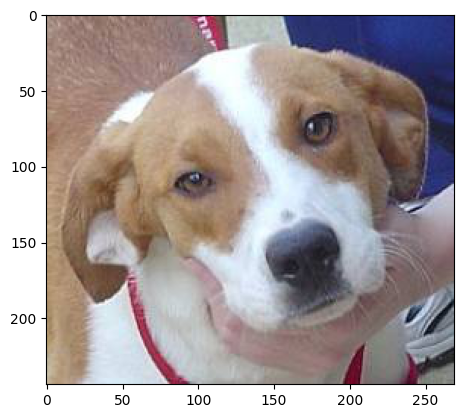

In [53]:
# displaying dog image
img = mpimg.imread('train/dog.10776.jpg')
imgplt = plt.imshow(img)
plt.show()

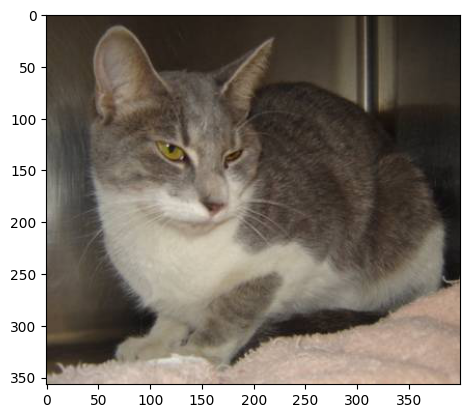

In [55]:
# displaying cat image
img = mpimg.imread('train/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [57]:
file_names = os.listdir('train')

for i in range(5):
    name = file_names[i]
    print(name[0:3])

cat
cat
cat
cat
cat


In [59]:
file_names = os.listdir('train')
dog_count = 0
cat_count = 0
for img_file in file_names:
    name = img_file[0:3]
    if name == 'cat':
        dog_count += 1
    else :
        cat_count += 1
print('Number of dog images :', dog_count)
print('Number of cat images :', cat_count)

Number of dog images : 12500
Number of cat images : 12500


# Resizing all the images

In [61]:
# creating a directory for resized images
os.mkdir('image resized')

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'image resized'

In [90]:
original_folder = 'train/'
resized_folder = 'image resized/'

cat = 0
dog = 0
for i in range(13500):
    filename = os.listdir(original_folder)[i] 
    if filename[0:3] == 'cat':
        if(cat < 1000):
            img_path = original_folder + filename

            img = Image.open(img_path)
            img = img.resize((224,224))
            img = img.convert('RGB')

            newImgPath = resized_folder+filename
            img.save(newImgPath)
            cat += 1
        else:
            continue
    elif filename[0:3] == 'dog':
        if(dog <= 1000):
            img_path = original_folder + filename

            img = Image.open(img_path)
            img = img.resize((224,224))
            img = img.convert('RGB')

            newImgPath = resized_folder+filename
            img.save(newImgPath)
            dog += 1
        else:
            continue
    else:
        continue

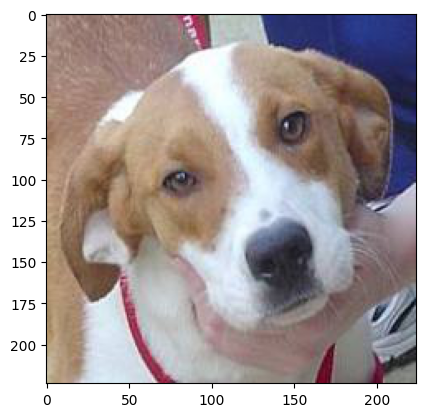

In [63]:
# displaying resized dog image
img = mpimg.imread('image resized/dog.10776.jpg')
imgplt = plt.imshow(img)
plt.show()

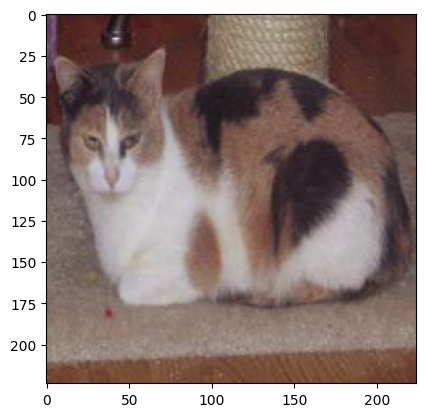

In [65]:
# displaying cat image
img = mpimg.imread('image resized/cat.1089.jpg')
imgplt = plt.imshow(img)
plt.show()

# Creating labels for resized images of dogs and cats

- cat --> 0
- dog --> 1

In [67]:
# creating a for loop to assign labels
filenames = os.listdir('image resized/')

labels = []

for i in range(2000):
    file_name = filenames[i]
    label = file_name[0:3]

    if label == 'dog':
        labels.append(1)
    else:
        labels.append(0)

In [69]:
print(filenames[0:5])
print(len(filenames))

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg']
2000


In [71]:
print(labels[0:5])
print(len(filenames))

[0, 0, 0, 0, 0]
2000


In [73]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1000 1000]


In [75]:
# Converting all the resized images to numpy arrays
import glob

In [77]:
image_directory = 'image resized/'
image_extension = ['png','jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [79]:
print(dog_cat_images)

[[[[ 87 163 205]
   [ 89 165 207]
   [ 92 168 210]
   ...
   [125 203 246]
   [123 200 246]
   [123 200 246]]

  [[ 87 163 205]
   [ 89 165 207]
   [ 92 168 210]
   ...
   [125 203 246]
   [124 201 247]
   [123 200 246]]

  [[ 87 163 205]
   [ 89 165 207]
   [ 92 168 210]
   ...
   [125 203 246]
   [124 201 247]
   [124 201 247]]

  ...

  [[ 57 123 158]
   [ 57 123 158]
   [ 56 124 159]
   ...
   [  0   2   1]
   [  0   2   1]
   [  0   2   1]]

  [[ 55 121 156]
   [ 56 122 157]
   [ 55 123 158]
   ...
   [  0   2   1]
   [  0   2   1]
   [  0   2   1]]

  [[ 54 120 155]
   [ 54 120 155]
   [ 53 121 156]
   ...
   [  0   2   1]
   [  0   2   1]
   [  0   2   1]]]


 [[[ 43  43  37]
   [ 47  47  41]
   [ 47  47  41]
   ...
   [181 207 207]
   [169 199 200]
   [161 194 197]]

  [[ 42  42  36]
   [ 46  46  40]
   [ 45  45  39]
   ...
   [176 202 202]
   [167 196 200]
   [164 197 200]]

  [[ 42  42  36]
   [ 44  44  38]
   [ 43  43  37]
   ...
   [168 194 194]
   [165 194 198]
   [168 200

In [81]:
type(dog_cat_images)

numpy.ndarray

In [83]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [85]:
x = dog_cat_images
y = np.asarray(labels)

# Train Test Split

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [89]:
print(x.shape, x_train.shape, x_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


* 1600 --> Training images
* 400  --> Test images

In [91]:
# scaling the data
x_train_scaled = x_train/255

x_test_scaled = x_test/255

In [45]:
print(x_train_scaled)

[[[[0.45098039 0.4627451  0.49411765]
   [0.44705882 0.45882353 0.49019608]
   [0.48235294 0.47843137 0.51372549]
   ...
   [0.98431373 0.99215686 0.99215686]
   [0.98823529 0.98431373 1.        ]
   [0.98431373 0.98039216 0.99607843]]

  [[0.24313725 0.25490196 0.28627451]
   [0.24313725 0.25098039 0.28235294]
   [0.2745098  0.27058824 0.30588235]
   ...
   [0.98431373 0.99215686 0.99215686]
   [0.99215686 0.98823529 1.        ]
   [0.98823529 0.98431373 1.        ]]

  [[0.22745098 0.23529412 0.26666667]
   [0.22352941 0.23137255 0.2627451 ]
   [0.25882353 0.25490196 0.29019608]
   ...
   [0.98823529 0.99607843 0.99607843]
   [1.         0.99607843 1.        ]
   [0.99607843 0.99215686 1.        ]]

  ...

  [[1.         1.         1.        ]
   [1.         1.         1.        ]
   [1.         1.         1.        ]
   ...
   [0.98823529 0.99607843 0.99607843]
   [0.99215686 1.         1.        ]
   [0.99215686 1.         1.        ]]

  [[0.99215686 0.99215686 0.99215686]
   [0.9

# Building the Neural Network

In [7]:
%pip install tensorflow-hub

Note: you may need to restart the kernel to use updated packages.


In [93]:
import tensorflow as tf
import tensorflow_hub as hub

In [95]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

class HubLayerWrapper(tf.keras.layers.Layer):
    def __init__(self, handle, **kwargs):
        super(HubLayerWrapper, self).__init__(**kwargs)
        self.hub_layer = hub.KerasLayer(handle, trainable=False)

    def call(self, inputs):
        return self.hub_layer(inputs)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    HubLayerWrapper(mobilenet_model),
    tf.keras.layers.Dense(2)
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hub_layer_wrapper_1                  │ (None, 1280)                │               0 │
│ (HubLayerWrapper)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │           2,562 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,562 (10.01 KB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [99]:
model.fit(x_train_scaled, y_train, epochs=5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 356ms/step - acc: 0.9413 - loss: 0.1717
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 355ms/step - acc: 0.9756 - loss: 0.0653
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 361ms/step - acc: 0.9819 - loss: 0.0521
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 359ms/step - acc: 0.9881 - loss: 0.0369
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 360ms/step - acc: 0.9900 - loss: 0.0315


In [101]:
score, acc = model.evaluate(x_test_scaled, y_test)
print('Test Loss = ', score)
print('Test Accuracy =', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - acc: 0.9875 - loss: 0.0582
Test Loss =  0.05819203704595566
Test Accuracy = 0.987500011920929


# Predictive System

Path of the image to be predicted:  image1.jpg


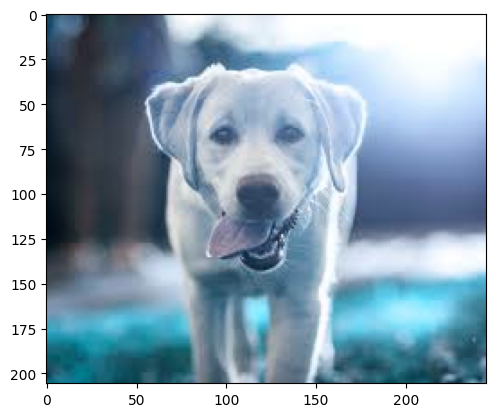

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The image represents a Dog..🐕


In [108]:
input_image_path = input('Path of the image to be predicted: ')
input_image=cv2.imread(input_image_path)
plt.imshow(input_image)
plt.show()

input_image_resize = cv2.resize(input_image,(224,224))
input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled,[1,224,224,3])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
    print("The image represents a Cat..🐈")
else:
    print("The image represents a Dog..🐕")

Path of the image to be predicted:  image2.jpg


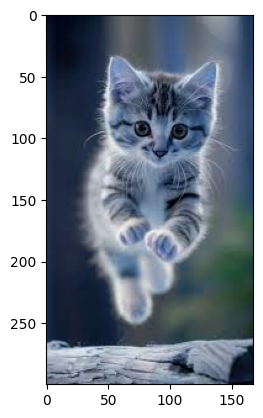

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
The image represents a Cat..🐈


In [110]:
input_image_path = input('Path of the image to be predicted: ')
input_image=cv2.imread(input_image_path)
plt.imshow(input_image)
plt.show()

input_image_resize = cv2.resize(input_image,(224,224))
input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled,[1,224,224,3])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
    print("The image represents a Cat..🐈")
else:
    print("The image represents a Dog..🐕")